In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('agg')
import matplotlib.pyplot as plt
import os
# from tqdm.notebook import  tqdm
from tqdm import  tqdm
import talib
import datetime
import math
import  mplfinance as mpf

import sys
sys.path.append('../../DataSource/baostock')
import datasource as DataSource
sys.path.append('../..')
import Utils
# 这个是筛选多少天上涨多少的，
codes = DataSource.getAStockCodes()
print(f'股票数量:{len(codes)},第一支股票:{codes[0]}')
code = codes[0]
dt = DataSource.getData(code)
dt.head()

股票数量:2459,第一支股票:sh.600000


,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,peTTM,pbMRQ,psTTM,pcfNcfTTM,isST
date,,,,,,,,,,,,,,,,,
2010-01-04,sh.600000,64.829140,64.947929,62.839423,62.928515,64.413379,66191338,1.419984e+09,1,0.835129,1,-2.3052,14.435065,2.877081,5.316299,7.091240,0
2010-01-05,sh.600000,63.581855,64.086709,61.740624,63.403671,62.928515,115147943,2.436891e+09,1,1.452808,1,0.7551,14.287342,2.898805,5.178308,7.144784,0
2010-01-06,sh.600000,63.225488,63.255185,62.007900,62.156386,63.403671,96782575,2.034174e+09,1,1.221095,1,-1.9672,14.006279,2.841779,5.076439,7.004231,0
2010-01-07,sh.600000,62.007900,62.483056,60.285458,60.760614,62.156386,85236072,1.761801e+09,1,1.075414,1,-2.2456,13.691757,2.777965,4.962444,6.846945,0
2010-01-08,sh.600000,60.404247,61.770322,60.285458,61.443652,60.760614,65707646,1.349532e+09,1,0.829026,1,1.1241,13.845672,2.809193,5.018229,6.923915,0


In [3]:
dt['preVolume'] = dt['volume'].shift() # 前一日的交易量
dt['preClose'] = dt['close'].shift() # 前一日的收盘价
dt['upRate'] = (dt['close']-dt['preClose'])/dt['preClose']*100
for i in [1,3,5]:
    # 计算多日后的涨幅
    dt[f'rate{i}'] = ((dt['close'].shift(-i)-dt['close'])/dt['close'])*100
dt.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,...,pbMRQ,psTTM,pcfNcfTTM,isST,preVolume,preClose,upRate,rate1,rate3,rate5
date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,sh.600000,64.829140,64.947929,62.839423,62.928515,64.413379,66191338,1.419984e+09,1,0.835129,...,2.877081,5.316299,7.091240,0,NaN,NaN,NaN,0.755073,-3.445021,-2.359604
2010-01-05,sh.600000,63.581855,64.086709,61.740624,63.403671,62.928515,115147943,2.436891e+09,1,1.452808,...,2.898805,5.178308,7.144784,0,66191338.0,62.928515,0.755073,-1.967213,-3.091335,-2.576112
2010-01-06,sh.600000,63.225488,63.255185,62.007900,62.156386,63.403671,96782575,2.034174e+09,1,1.221095,...,2.841779,5.076439,7.004231,0,115147943.0,63.403671,-1.967213,-2.245581,-1.146679,-5.255614
2010-01-07,sh.600000,62.007900,62.483056,60.285458,60.760614,62.156386,85236072,1.761801e+09,1,1.075414,...,2.777965,4.962444,6.846945,0,96782575.0,62.156386,-2.245581,1.124145,1.661779,-2.394917
2010-01-08,sh.600000,60.404247,61.770322,60.285458,61.443652,60.760614,65707646,1.349532e+09,1,0.829026,...,2.809193,5.018229,6.923915,0,85236072.0,60.760614,1.124145,0.000000,-4.156597,-3.141614


In [4]:
VOLUME_ZOOM_THRESHOLD = 2 # 交易量涨幅阈值
dt2 = dt.loc[dt['volume']> VOLUME_ZOOM_THRESHOLD *  dt['preVolume'], :] # 筛选超过某个阈值的
print(len(dt2))
dt2.head()

190


,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,...,pbMRQ,psTTM,pcfNcfTTM,isST,preVolume,preClose,upRate,rate1,rate3,rate5
date,,,,,,,,,,,,,,,,,,,,,
2010-02-25,sh.600000,58.652108,61.770322,58.652108,61.592138,58.384833,194475975,3.998875e+09,1,2.453681,...,2.815982,5.030356,6.940647,0,38978358.0,58.384833,5.493388,0.000000,0.000000,0.000000
2010-03-11,sh.600000,62.364267,64.740049,62.067294,63.255185,61.592138,230271759,4.943091e+09,1,2.905312,...,2.892016,5.166181,7.128052,0,0.0,61.592138,2.700096,-1.220657,-0.516432,1.877934
2010-03-22,sh.600000,64.888535,66.373398,64.888535,65.957637,64.740049,96636042,2.147457e+09,1,1.219246,...,3.015572,5.386895,7.432583,0,44756709.0,64.740049,1.880734,-0.945520,-2.701486,3.466907
2010-03-31,sh.600000,68.511602,68.570996,67.412803,67.650381,68.244326,54201365,1.237977e+09,1,0.683852,...,3.092964,5.525145,7.623334,0,0.0,68.244326,-0.870322,0.307287,0.921861,-0.877963
2010-04-19,sh.600000,64.413379,64.413379,60.849706,61.057587,65.512178,123269959,2.578443e+09,1,1.555283,...,2.671636,4.930102,4.754373,0,54964770.0,65.512178,-6.799637,-0.097276,-1.799611,-0.486381


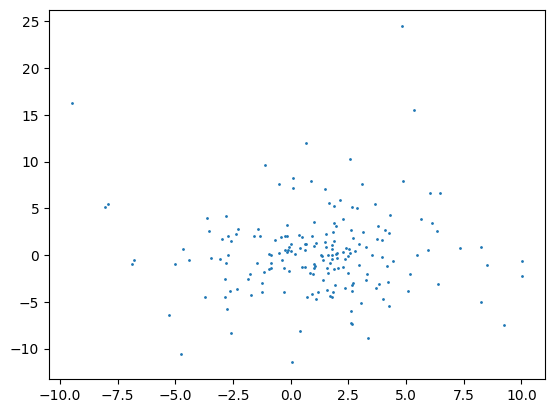

In [5]:
# 这里用散点图
plt.scatter(dt2['upRate'], dt2['rate5'],s=1)

In [ ]:
# 接下来进行全部股票的
VOLUME_ZOOM_THRESHOLD = 2 # 交易量涨幅阈值
dts = []
for i in tqdm(range(len(codes))):
    code = codes[i]
    dt = DataSource.getData(code)
    dt['preVolume'] = dt['volume'].shift() # 前一日的交易量
    dt['preClose'] = dt['close'].shift() # 前一日的收盘价
    dt['upRate'] = (dt['close']-dt['preClose'])/dt['preClose']*100
    for i in [1,3,5]:
        # 计算多日后的涨幅
        dt[f'rate{i}'] = ((dt['close'].shift(-i)-dt['close'])/dt['close'])*100
    dt2 = dt.loc[(dt['volume']> VOLUME_ZOOM_THRESHOLD *  dt['preVolume']) & (abs(dt['upRate']) < 11), :] # 筛选超过某个阈值的,然后没有超过涨停跌停的
    if len(dt2) > 0:
        dts.append(dt2)
dt_all = pd.concat(dts)

 65%|███████████████████████████████████████████████████                           | 1609/2459 [01:04<00:26, 32.24it/s]

In [ ]:
plt.scatter(dt_all['upRate'], dt_all['rate1'],s=1, alpha=0.5)

In [ ]:
plt.scatter(dt_all['upRate'], dt_all['rate3'],s=1, alpha=0.5)

In [ ]:
plt.scatter(dt_all['upRate'], dt_all['rate5'],s=1, alpha=0.5)

实在是看不出有什么规律